In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [145]:
df=pd.read_csv("/home/asad-shareef/Downloads/maizeexp.csv")
df=df.sort_values(by=["district","crop"])
df=df[df["crop"]=="maize"]
df["flag"]=df["kg/acre"]==0
df=df.drop("Unnamed: 0",axis=1)
df

,district,year,crop,germ_temp,veg_temp,flow_temp,fruit_temp,germ_rh,veg_rh,flow_rh,fruit_rh,germ_prec,veg_prec,flow_prec,fruit_prec,n__g/kg,soc__g/kg,soil_ph,kg/acre,flag
0,attock,1981,maize,17.29,25.42,31.63,36.22,58.97,43.16,32.49,17.88,139.91,44.09,38.03,21.77,1.538567,16.76787,7.54444,444.534413,False
1,attock,1982,maize,14.47,22.55,26.37,32.66,70.62,59.10,58.20,36.26,112.51,153.08,89.00,15.01,1.538567,16.76787,7.54444,436.842105,False
2,attock,1983,maize,16.15,20.60,27.58,32.44,51.31,61.80,53.09,34.13,87.07,250.12,59.68,32.39,1.538567,16.76787,7.54444,451.012146,False
3,attock,1984,maize,21.19,25.17,34.26,37.32,41.60,41.09,15.47,22.36,53.31,35.78,2.24,34.25,1.538567,16.76787,7.54444,446.558704,False
4,attock,1985,maize,21.62,25.66,32.00,36.56,26.45,41.04,21.80,16.81,33.17,49.84,25.84,2.24,1.538567,16.76787,7.54444,411.336032,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1535,vehari,2020,maize,19.81,26.14,33.87,37.26,66.61,57.37,32.32,35.73,204.12,18.89,14.65,38.87,1.546484,9.56018,7.59187,3721.457490,False
1536,vehari,2021,maize,24.60,28.76,34.30,36.42,34.03,25.16,27.99,35.88,9.53,6.12,39.38,35.62,1.546484,9.56018,7.59187,2739.676105,False
1537,vehari,2022,maize,27.13,33.59,36.50,36.61,27.91,13.80,19.74,30.52,3.36,0.00,15.05,38.15,1.546484,9.56018,7.59187,3327.165840,False
1538,vehari,2023,maize,23.64,28.18,32.10,34.05,42.64,38.96,36.27,52.08,47.16,16.55,109.03,45.76,1.546484,9.56018,7.59187,2886.711576,False


In [146]:
df.isnull().sum()

district      0
year          0
crop          0
germ_temp     0
veg_temp      0
flow_temp     0
fruit_temp    0
germ_rh       0
veg_rh        0
flow_rh       0
fruit_rh      0
germ_prec     0
veg_prec      0
flow_prec     0
fruit_prec    0
n__g/kg       0
soc__g/kg     0
soil_ph       0
kg/acre       0
flag          0
dtype: int64

In [147]:
low=df["kg/acre"].quantile(0.01)
high=df["kg/acre"].quantile(0.99)
df=df[(df["kg/acre"]>=low)&(df["kg/acre"]<=high)]

In [148]:
df["soil"]=df["n__g/kg"]+df["soc__g/kg"]
df["total_prec"]=df["germ_prec"]+df["veg_prec"]+df["flow_prec"]+df["fruit_prec"]
df["avg_rh"]=(df["germ_rh"]+df["veg_rh"]+df["flow_rh"]+df["fruit_rh"])/4

In [149]:
df.columns

Index(['district', 'year', 'crop', 'germ_temp', 'veg_temp', 'flow_temp',
       'fruit_temp', 'germ_rh', 'veg_rh', 'flow_rh', 'fruit_rh', 'germ_prec',
       'veg_prec', 'flow_prec', 'fruit_prec', 'n__g/kg', 'soc__g/kg',
       'soil_ph', 'kg/acre', 'flag', 'soil', 'total_prec', 'avg_rh'],
      dtype='str')

In [150]:
dfc=df.drop(["district","crop"],axis=1)

In [151]:
dfc.corr()

,year,germ_temp,veg_temp,flow_temp,fruit_temp,germ_rh,veg_rh,flow_rh,fruit_rh,germ_prec,...,flow_prec,fruit_prec,n__g/kg,soc__g/kg,soil_ph,kg/acre,flag,soil,total_prec,avg_rh
year,1.000000,0.194870,0.096668,0.034477,-0.269214,0.111097,0.147990,0.162658,0.516800,0.080187,...,0.086581,0.328903,-0.004171,-0.004163,0.006794,0.725871,-0.282623,-0.004207,0.181120,0.256146
germ_temp,0.194870,1.000000,0.696293,0.628309,0.423015,-0.769132,-0.648719,-0.493186,0.061305,-0.597850,...,-0.317099,-0.135521,-0.348328,-0.492407,0.200467,0.204804,-0.092853,-0.485340,-0.485256,-0.644405
veg_temp,0.096668,0.696293,1.000000,0.751945,0.493207,-0.569467,-0.843298,-0.580135,-0.087830,-0.534122,...,-0.374097,-0.172465,-0.393843,-0.543795,0.220711,0.147729,-0.058500,-0.536764,-0.537466,-0.690221
flow_temp,0.034477,0.628309,0.751945,1.000000,0.621609,-0.638281,-0.723692,-0.776017,-0.207783,-0.547256,...,-0.554712,-0.247707,-0.377723,-0.500690,0.212211,0.099222,-0.048513,-0.495491,-0.605355,-0.756076
fruit_temp,-0.269214,0.423015,0.493207,0.621609,1.000000,-0.503687,-0.542521,-0.600198,-0.679234,-0.482193,...,-0.544303,-0.624798,-0.467491,-0.610743,0.280875,-0.086826,0.055373,-0.604971,-0.699427,-0.700979
germ_rh,0.111097,-0.769132,-0.569467,-0.638281,-0.503687,1.000000,0.688345,0.633557,0.226598,0.761773,...,0.436627,0.327634,0.270894,0.400479,-0.164846,0.092297,0.055254,0.393684,0.641365,0.852190
veg_rh,0.147990,-0.648719,-0.843298,-0.723692,-0.542521,0.688345,1.000000,0.747239,0.315727,0.699407,...,0.462384,0.304783,0.297793,0.427815,-0.168368,0.121302,0.037426,0.421266,0.699602,0.887772
flow_rh,0.162658,-0.493186,-0.580135,-0.776017,-0.600198,0.633557,0.747239,1.000000,0.439640,0.644290,...,0.697078,0.331860,0.227801,0.302758,-0.128529,0.117101,0.039542,0.299564,0.729456,0.875353
fruit_rh,0.516800,0.061305,-0.087830,-0.207783,-0.679234,0.226598,0.315727,0.439640,1.000000,0.329790,...,0.450138,0.723659,0.111151,0.137930,-0.075793,0.341994,-0.116090,0.137097,0.599985,0.543882
germ_prec,0.080187,-0.597850,-0.534122,-0.547256,-0.482193,0.761773,0.699407,0.644290,0.329790,1.000000,...,0.581061,0.425017,0.246767,0.319723,-0.148334,0.035704,0.039999,0.316873,0.823982,0.788703


In [152]:
df=df.drop([ 'germ_rh', 'veg_rh', 'flow_rh', 'fruit_rh', 'n__g/kg', 'soc__g/kg','avg_rh'],axis=1)

<Axes: xlabel='total_prec', ylabel='kg/acre'>

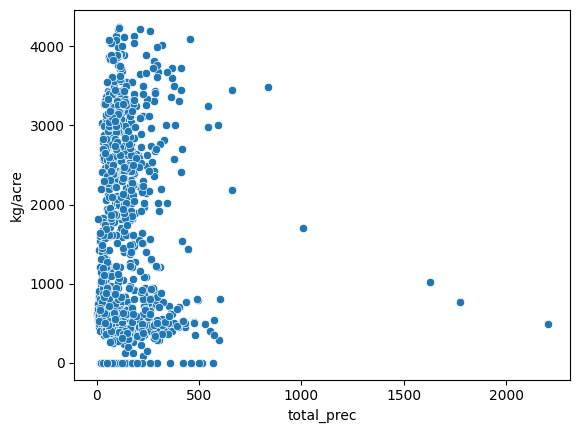

In [153]:
sns.scatterplot(x="total_prec",y="kg/acre",data=df)

 ...]

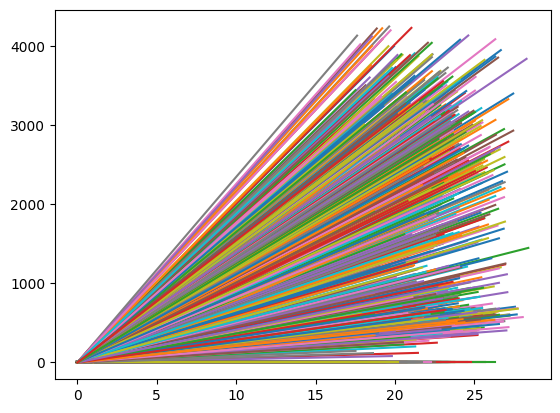

In [154]:
a=df["germ_temp"],df["district"]=="okara"
b=df["kg/acre"],df["district"]=="okara"
plt.plot(a,b)

In [155]:
df[df["total_prec"]>700]

,district,year,crop,germ_temp,veg_temp,flow_temp,fruit_temp,germ_prec,veg_prec,flow_prec,fruit_prec,soil_ph,kg/acre,flag,soil,total_prec
39,attock,2020,maize,16.04,21.97,26.55,29.35,484.90,195.04,453.63,641.79,7.54444,762.064977,False,18.306437,1775.36
215,chakwal,2020,maize,15.90,21.63,25.96,28.77,382.51,75.12,417.54,751.41,7.57034,1026.720648,False,18.048532,1626.58
259,dera ghazi khan,2020,maize,18.85,25.21,31.37,33.47,479.31,46.16,125.69,184.18,7.89200,3489.878542,False,9.138000,835.34
655,khushab,2020,maize,16.42,22.21,27.25,30.32,274.88,61.16,232.24,436.93,7.90531,1700.404858,False,12.472265,1005.21
1271,rawalpindi,2020,maize,15.57,21.08,25.48,28.08,484.10,131.19,597.20,990.99,6.77083,493.408920,False,28.791581,2203.48


In [156]:
df["water_stress"]=df["total_prec"]>700

In [157]:
df.info()

<class 'pandas.DataFrame'>
Index: 1524 entries, 0 to 1539
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   district      1524 non-null   str    
 1   year          1524 non-null   int64  
 2   crop          1524 non-null   str    
 3   germ_temp     1524 non-null   float64
 4   veg_temp      1524 non-null   float64
 5   flow_temp     1524 non-null   float64
 6   fruit_temp    1524 non-null   float64
 7   germ_prec     1524 non-null   float64
 8   veg_prec      1524 non-null   float64
 9   flow_prec     1524 non-null   float64
 10  fruit_prec    1524 non-null   float64
 11  soil_ph       1524 non-null   float64
 12  kg/acre       1524 non-null   float64
 13  flag          1524 non-null   bool   
 14  soil          1524 non-null   float64
 15  total_prec    1524 non-null   float64
 16  water_stress  1524 non-null   bool   
dtypes: bool(2), float64(12), int64(1), str(2)
memory usage: 214.1 KB


In [158]:
df.describe()

,year,germ_temp,veg_temp,flow_temp,fruit_temp,germ_prec,veg_prec,flow_prec,fruit_prec,soil_ph,kg/acre,soil,total_prec
count,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000
mean,2002.308399,21.648366,28.161155,34.113858,37.140906,36.494980,25.637841,20.433707,39.471562,7.646558,1232.127618,12.243389,122.038091
std,12.628513,2.488090,2.523541,2.417991,1.673286,50.628408,31.981980,30.273396,53.066822,0.331740,1089.169302,4.305119,127.452861
min,1981.000000,13.880000,19.610000,24.610000,28.080000,0.000000,0.000000,0.000000,0.000000,6.358080,0.000000,6.985000,0.970000
25%,1991.000000,19.947500,26.510000,32.790000,36.217500,7.952500,5.585000,5.250000,10.660000,7.555000,511.234818,9.138000,52.935000
50%,2002.000000,21.650000,28.285000,34.490000,37.440000,19.995000,16.110000,13.350000,26.020000,7.711910,635.425101,11.541315,91.030000
75%,2013.000000,23.320000,30.025000,35.860000,38.412500,45.347500,33.925000,25.795000,49.375000,7.878000,2063.804554,13.754063,152.880000
max,2024.000000,28.390000,34.600000,38.610000,40.210000,484.900000,258.470000,597.200000,990.990000,8.030080,4246.000000,28.791581,2203.480000


In [159]:
df["district"].value_counts()

district
attock             44
bahawalpur         44
bhakkar            44
chakwal            44
dera ghazi khan    44
faisalabad         44
gujranwala         44
gujrat             44
hafizabad          44
khanewal           44
khushab            44
layyah             44
lodhran            44
mandi bahauddin    44
mianwali           44
multan             44
muzaffargarh       44
nankana sahib      44
pakpattan          44
rahim yar khan     44
rajanpur           44
rawalpindi         44
sahiwal            44
sheikhupura        44
toba tek singh     44
bhawalnagar        43
lahore             43
narowal            43
okara              43
sargodha           43
vehari             43
jhelum             42
kasur              42
jhang              41
sialkot            41
Name: count, dtype: int64

In [160]:
df.columns

Index(['district', 'year', 'crop', 'germ_temp', 'veg_temp', 'flow_temp',
       'fruit_temp', 'germ_prec', 'veg_prec', 'flow_prec', 'fruit_prec',
       'soil_ph', 'kg/acre', 'flag', 'soil', 'total_prec', 'water_stress'],
      dtype='str')

In [161]:
cat_col=["district",'crop']
num_col=[ 'year','germ_temp', 'veg_temp', 'flow_temp', 'fruit_temp',
        'germ_prec', 'veg_prec',
       'flow_prec', 'fruit_prec', 'soil_ph','soil','total_prec']

In [162]:
df=pd.get_dummies(df,columns=cat_col)

In [163]:
df

,year,germ_temp,veg_temp,flow_temp,fruit_temp,germ_prec,veg_prec,flow_prec,fruit_prec,soil_ph,...,district_rahim yar khan,district_rajanpur,district_rawalpindi,district_sahiwal,district_sargodha,district_sheikhupura,district_sialkot,district_toba tek singh,district_vehari,crop_maize
0,1981,17.29,25.42,31.63,36.22,139.91,44.09,38.03,21.77,7.54444,...,False,False,False,False,False,False,False,False,False,True
1,1982,14.47,22.55,26.37,32.66,112.51,153.08,89.00,15.01,7.54444,...,False,False,False,False,False,False,False,False,False,True
2,1983,16.15,20.60,27.58,32.44,87.07,250.12,59.68,32.39,7.54444,...,False,False,False,False,False,False,False,False,False,True
3,1984,21.19,25.17,34.26,37.32,53.31,35.78,2.24,34.25,7.54444,...,False,False,False,False,False,False,False,False,False,True
4,1985,21.62,25.66,32.00,36.56,33.17,49.84,25.84,2.24,7.54444,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1535,2020,19.81,26.14,33.87,37.26,204.12,18.89,14.65,38.87,7.59187,...,False,False,False,False,False,False,False,False,True,True
1536,2021,24.60,28.76,34.30,36.42,9.53,6.12,39.38,35.62,7.59187,...,False,False,False,False,False,False,False,False,True,True
1537,2022,27.13,33.59,36.50,36.61,3.36,0.00,15.05,38.15,7.59187,...,False,False,False,False,False,False,False,False,True,True
1538,2023,23.64,28.18,32.10,34.05,47.16,16.55,109.03,45.76,7.59187,...,False,False,False,False,False,False,False,False,True,True


In [164]:
x=df.drop("kg/acre",axis=1)
y=df["kg/acre"]

In [165]:
from sklearn.model_selection import train_test_split

In [166]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0,shuffle=True)

In [167]:
x_train

,year,germ_temp,veg_temp,flow_temp,fruit_temp,germ_prec,veg_prec,flow_prec,fruit_prec,soil_ph,...,district_rahim yar khan,district_rajanpur,district_rawalpindi,district_sahiwal,district_sargodha,district_sheikhupura,district_sialkot,district_toba tek singh,district_vehari,crop_maize
717,1994,23.24,25.39,33.53,38.19,14.38,25.55,10.86,1.85,7.74795,...,False,False,False,False,False,False,False,False,False,True
967,2024,22.68,27.89,36.58,39.42,14.05,39.81,0.40,12.19,7.55500,...,False,False,False,False,False,False,False,False,False,True
1413,1986,18.71,26.19,31.65,36.39,69.95,55.34,22.76,50.01,7.20303,...,False,False,False,False,False,False,True,False,False,True
1472,2001,23.54,28.63,37.26,38.07,6.46,36.73,10.75,34.61,7.84247,...,False,False,False,False,False,False,False,True,False,True
678,1999,23.04,30.92,35.59,37.29,4.10,0.35,7.17,47.95,6.35808,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,2005,23.20,29.24,33.31,39.06,30.51,3.06,18.06,0.73,7.68558,...,False,False,False,False,False,False,False,False,False,True
844,1989,19.41,25.06,32.24,36.59,46.70,5.84,3.98,15.14,7.73821,...,False,False,False,False,False,False,False,False,False,True
1227,2020,20.54,26.89,33.14,35.52,214.76,28.28,73.00,76.10,7.98215,...,False,True,False,False,False,False,False,False,False,True
565,2018,24.11,29.87,34.91,36.05,6.97,9.90,5.99,95.38,7.69263,...,False,False,False,False,False,False,False,False,False,True


In [168]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
ss=StandardScaler()
mm=MinMaxScaler()

In [169]:
# x_train[num_col]=ss.fit_transform(x_train[num_col])
# x_test[num_col]=ss.transform(x_test[num_col])

In [170]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

In [171]:
dtr=DecisionTreeRegressor()
rfr=RandomForestRegressor()
gbr=GradientBoostingRegressor(
    n_estimators=800,
    max_depth=10,
    learning_rate=0.01,
    subsample=0.8,
    min_weight_fraction_leaf=0.0,
    min_samples_leaf=2,
    random_state=0,
    min_samples_split=0.01
)
xgb=XGBRegressor(
    n_estimators=800,
    max_depth=10,
    learning_rate=0.01,
    subsample=0.8
)

In [172]:
rfr.fit(x_train,y_train)
rfr_pred=rfr.predict(x_test)
rfr_pred_t=rfr.predict(x_train)

In [173]:
dtr.fit(x_train,y_train)
dtr_pred=dtr.predict(x_test)
dtr_pred_t=dtr.predict(x_train)

In [174]:
gbr.fit(x_train,y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",800
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",0.01
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",10
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in the

In [175]:
gbr_pred=gbr.predict(x_test)
gbr_pred_t=gbr.predict(x_train)

In [176]:
xgb.fit(x_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [177]:
xgb_pred=xgb.predict(x_test)
xgb_pred_t=xgb.predict(x_train)

In [178]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [179]:
print("r2_gbr_t=",r2_score(y_train,gbr_pred_t))
print("r2_xgb_t=",r2_score(y_train,xgb_pred_t))
print("r2_rfr_t=",r2_score(y_train,rfr_pred_t))
print("r2_dtr_t=",r2_score(y_train,dtr_pred_t))

r2_gbr_t= 0.9955378199190829
r2_xgb_t= 0.9985140307911088
r2_rfr_t= 0.9806217773063396
r2_dtr_t= 1.0


In [180]:
print("r2_gbr=",r2_score(y_test,gbr_pred))
print("r2_xgb=",r2_score(y_test,xgb_pred))
print("r2_rfr=",r2_score(y_test,rfr_pred))
print("r2_dtr=",r2_score(y_test,dtr_pred))

r2_gbr= 0.9218660655696986
r2_xgb= 0.9156972792849623
r2_rfr= 0.9068811663641783
r2_dtr= 0.847716056618189


In [181]:
print("mae_gbr_t=",mean_absolute_error(y_train,gbr_pred_t))
print("mae_xgb_t=",mean_absolute_error(y_train,xgb_pred_t))
print("mae_rfr_t=",mean_absolute_error(y_train,rfr_pred_t))
print("mae_dtr_t=",mean_absolute_error(y_train,dtr_pred_t))

mae_gbr_t= 43.61895332006278
mae_xgb_t= 26.420940784196898
mae_rfr_t= 81.61836810026229
mae_dtr_t= 1.398935656951797e-16


In [182]:
print("mae_gbr=",mean_absolute_error(y_test,gbr_pred))
print("mae_xgb=",mean_absolute_error(y_test,xgb_pred))
print("mae_rfr=",mean_absolute_error(y_test,rfr_pred))
print("mae_dtr=",mean_absolute_error(y_test,dtr_pred))

mae_gbr= 183.31488133460405
mae_xgb= 185.40971037940906
mae_rfr= 199.6565221187879
mae_dtr= 242.88120367172772


In [194]:
train_errors=[]
test_errors=[]
for train_staged_pred, test_staged_pred in zip(
    gbr.staged_predict(x_train),
    gbr.staged_predict(x_test)
):
    train_errors.append(
        (mean_squared_error(y_train,train_staged_pred))
    )
    test_errors.append(
       (mean_squared_error(y_test,test_staged_pred))
    )
    

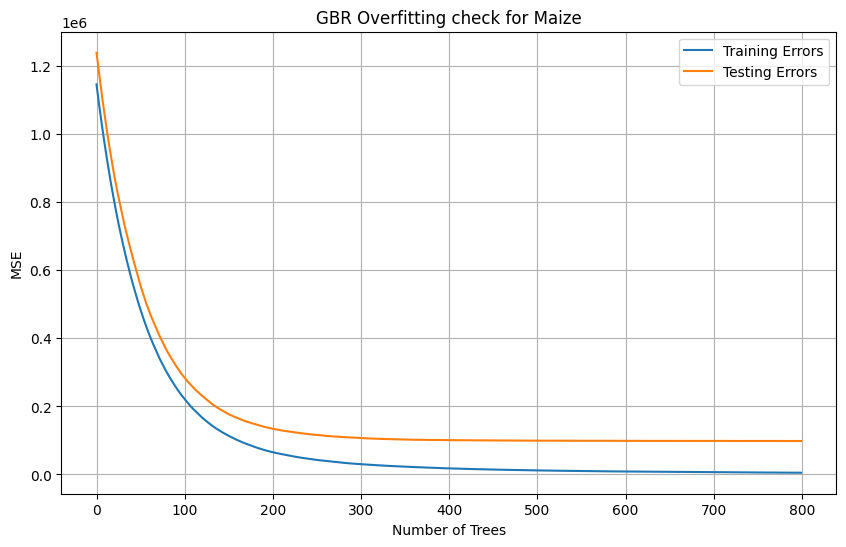

In [195]:
plt.figure(figsize=(10,6))
plt.plot(
    train_errors,
    label="Training Errors"
)
plt.plot(
    test_errors,
    label="Testing Errors"
)
plt.xlabel("Number of Trees")
plt.ylabel("MSE")
plt.title("GBR Overfitting check for Maize")
plt.legend()
plt.grid(True)
plt.show()

In [185]:
import joblib
joblib.dump(gbr,"model_maize.pkl")

['model_maize.pkl']

In [186]:
import joblib

feature_columns = x.columns.tolist()

joblib.dump(
    feature_columns,
    "feature_columns_maize.pkl"
)

['feature_columns_maize.pkl']

Text(0.5, 1.0, 'Maize Crop (Actual vs Predicted )')

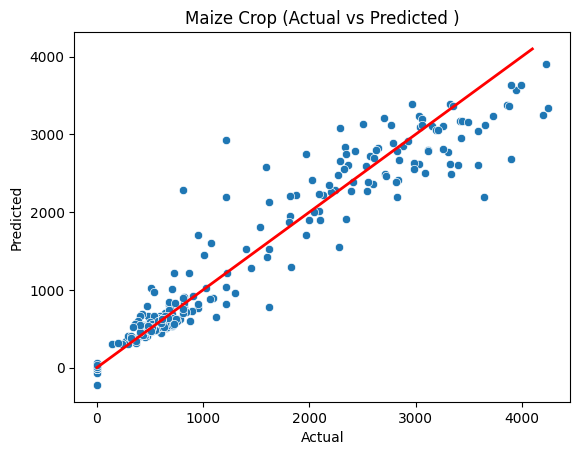

In [187]:
sns.scatterplot(x=y_test,y=gbr_pred)
plt.plot([0,4100],
         [0,4100],
         color='r',
         linestyle='-',
         linewidth=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Maize Crop (Actual vs Predicted )")

In [188]:
import shap

In [189]:
exp=shap.Explainer(gbr)
shap_val=exp(x.drop("year",axis=1))

In [190]:
np.shape(shap_val.values)

(1524, 49)

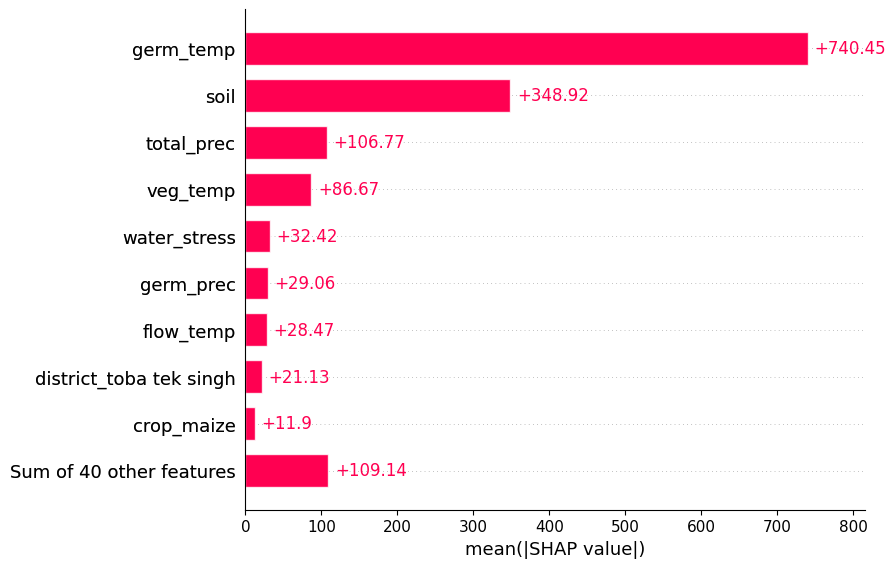

In [191]:
shap.plots.bar(shap_val)